# **Trabajo práctico 3**

*Santiago Volio*


In [ ]:
#Ejercicio 1

### Info

- Kilómetros recorridos: 4000  
- Precio del auto: $16,000  
Regla: Precio = a × Kilómetros  

---

### 1. Cálculo de "a" (precio por kilómetro)

a = 16000 / 4000 = 4  

El valor de ''a'' es 4 dólares por kilómetro.

---

### 2. Función de costo (error)

J(a) = (1/2) × (a × x - y)²  

Sustituyendo los valores:  
J(a) = (1/2) × (4000 * a - 16000)²  

---

### 3. Derivada de la función de costo

dJ/da = x × (a × x - y)  

Sustituyendo:  
dJ/da = 4000 * (4000 * a - 16000)

---

### 4. Explicación de la derivada

- La derivada muestra cómo cambia el **costo (error)** cuando modificamos el valor de **a**.  
- Cuando la derivada es **0**, el costo no cambia, lo que indica que llegó a un límite (mínimo o máximo).  
- Si se iguala la derivada a cero:  
  4000 × (4000a - 16000) = 0  
  Entonces, a = 4  
- Esto significa que el precio por kilómetro que minimiza el error es 4.

---

### 5) Verificación con gradiente descendente
Valor final de "a" después del aprendizaje: 4.000000000000001  
Costo final: 0.000000000003637978807091713  

dJ/da representa la pendiente (m) de la función de costo con respecto a "a".  
En otras palabras, nos dice:
- **Si el costo está aumentando o disminuyendo** cuando cambiamos "a".  
- En qué dirección orientarse para reducir el error.  

Cuando dJ/da = 0,  quiere decir que el punto donde el error es **mínimo**, es decir, el valor óptimo de "a".


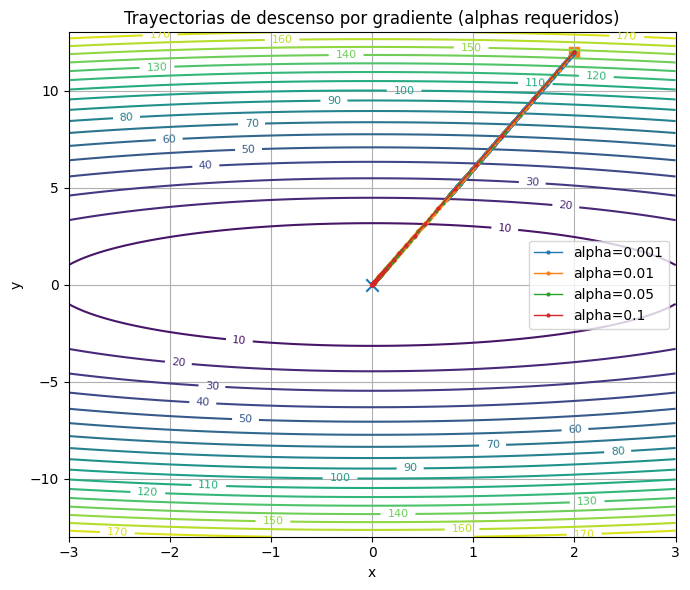

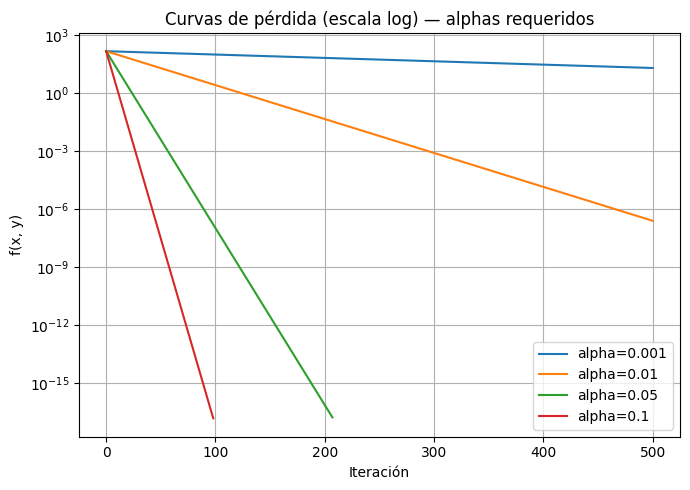

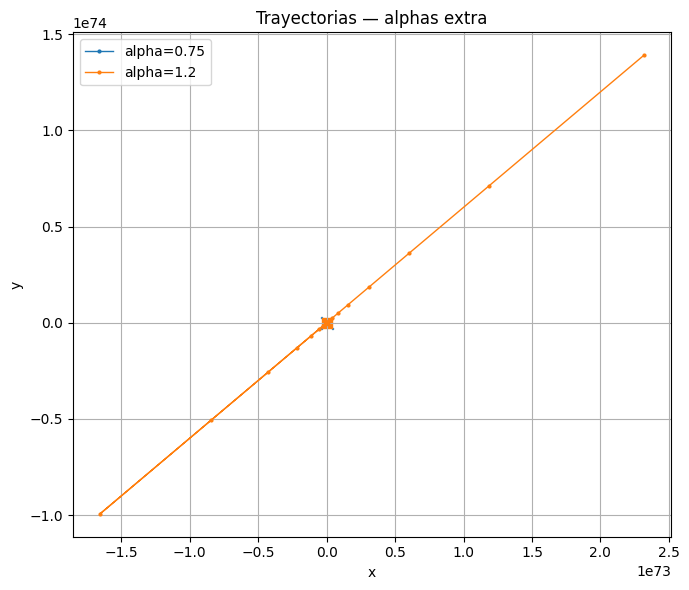

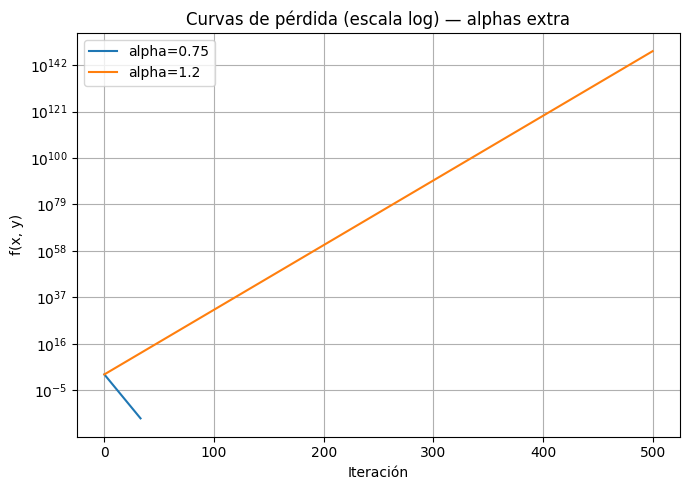

----------------------------------------------------------------------------------------------------------------------------------------------------------------
PARTE B: 
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1) ¿Cuál converge más rápido (entre [0.001, 0.01, 0.05, 0.1])?  -> alpha = 0.1
   Iteraciones/medida usada: 63
2) ¿Alguno diverge? -> [1.2]
   ¿Alguno 'salta'/oscila? -> No se detectó oscilación significativa en los requeridos; alpha=0.75 (extra) oscila.
3) Comportamiento observado:
   - Con una función cuadrática f(x,y)=x^2+y^2, el descenso por gradiente converge si 0<alpha<1.
   - Alphas pequeños convergen de forma estable pero lenta; alphas más grandes aceleran, hasta que aparecen oscilaciones (0.5<alpha<1).
   - Para alpha >= 1 el método diverge en este problema.
   - Desde (2,12), alpha=0.1 fue el más rápido entre los requeridos; alpha=0.75 muestra oscila

In [9]:

# Ejercicio 2

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Función objetivo
# f(x, y) = x^2 + y^2  (mínimo global en (0, 0))
def f(xy):
    x, y = xy
    return x**2 + y**2

def grad_f(xy):
    x, y = xy
    return np.array([2*x, 2*y])

#  Descenso por gradiente
def gradient_descent(alpha, x0, max_iters=500, tol=1e-8):
    xk = np.array(x0, dtype=float)
    path = [xk.copy()]
    losses = [f(xk)]
    grads = [np.linalg.norm(grad_f(xk))]
    oscillations = 0

    for k in range(1, max_iters + 1):
        gk = grad_f(xk)
        xk1 = xk - alpha * gk
        oscillations += int(np.any(np.sign(xk1) == -np.sign(xk)) and np.linalg.norm(xk1) > 0)
        path.append(xk1.copy())
        losses.append(f(xk1))
        grads.append(np.linalg.norm(grad_f(xk1)))
        if np.linalg.norm(gk) < tol:
            return np.array(path), np.array(losses), np.array(grads), k, False, oscillations
        xk = xk1

    diverged = (np.any(np.isnan(losses)) or np.any(np.isinf(losses)) or losses[-1] > losses[0])
    return np.array(path), np.array(losses), np.array(grads), max_iters, diverged, oscillations

# Experimentos
x0 = (2.0, 12.0)
alphas_requeridos = [0.001, 0.01, 0.05, 0.1]
alphas_extras = [0.75, 1.2]
alphas = alphas_requeridos + alphas_extras

resultados = {}

for a in alphas:
    path, losses, grads, iters, diverged, oscillations = gradient_descent(a, x0)
    resultados[a] = {
        "path": path,
        "losses": losses,
        "grads": grads,
        "iters": iters,
        "diverged": diverged,
        "oscillations": oscillations
    }

# Gráficas
xlin = np.linspace(-3, 3, 200)
ylin = np.linspace(-13, 13, 200)
XX, YY = np.meshgrid(xlin, ylin)
ZZ = XX**2 + YY**2

#  Trayectorias
plt.figure(figsize=(7, 6))
cs = plt.contour(XX, YY, ZZ, levels=20)
plt.clabel(cs, inline=True, fontsize=8)
for a in alphas_requeridos:
    path = resultados[a]["path"]
    plt.plot(path[:, 0], path[:, 1], marker='o', linewidth=1, markersize=2, label=f"alpha={a}")
plt.scatter([0], [0], marker='x', s=80)
plt.scatter([x0[0]], [x0[1]], marker='s', s=50)
plt.title("Trayectorias de descenso por gradiente (alphas requeridos)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#  Pérdida vs iteraciones
plt.figure(figsize=(7, 5))
for a in alphas_requeridos:
    losses = resultados[a]["losses"]
    plt.plot(losses, label=f"alpha={a}")
plt.yscale('log')
plt.xlabel("Iteración")
plt.ylabel("f(x, y)")
plt.title("Curvas de pérdida (escala log) — alphas requeridos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Trayectorias
plt.figure(figsize=(7, 6))
for a in alphas_extras:
    path = resultados[a]["path"]
    plt.plot(path[:, 0], path[:, 1], marker='o', linewidth=1, markersize=2, label=f"alpha={a}")
plt.scatter([0], [0], marker='x', s=80)
plt.scatter([x0[0]], [x0[1]], marker='s', s=50)
plt.title("Trayectorias — alphas extra")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Curvas de pérdida
plt.figure(figsize=(7, 5))
for a in alphas_extras:
    losses = resultados[a]["losses"]
    plt.plot(losses, label=f"alpha={a}")
plt.yscale('log')
plt.xlabel("Iteración")
plt.ylabel("f(x, y)")
plt.title("Curvas de pérdida (escala log) — alphas extra")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Respuestas
def convergencia_mas_rapida(resultados_dict, alphas_lista):
    mejor_alpha = None
    mejor_metric = np.inf
    for a in alphas_lista:
        r = resultados_dict[a]
        losses = r["losses"]
        below = np.where(losses < 1e-10)[0]
        metric = below[0] if len(below) > 0 else 1_000 + losses[-1]
        if metric < mejor_metric:
            mejor_metric = metric
            mejor_alpha = a
    return mejor_alpha, mejor_metric

alpha_mas_rapido, metric = convergencia_mas_rapida(resultados, alphas_requeridos)
divergen = [a for a in alphas if resultados[a]["diverged"]]
oscilan = []
for a in alphas:
    r = resultados[a]
    losses = r["losses"]
    non_monotone = np.any(np.diff(losses) > 0)
    if (r["oscillations"] > 0) and not r["diverged"] and non_monotone:
        oscilan.append(a)

comentarios = [
    "Con una función cuadrática f(x,y)=x^2+y^2, el descenso por gradiente converge si 0<alpha<1.",
    "Alphas pequeños convergen de forma estable pero lenta; alphas más grandes aceleran, hasta que aparecen oscilaciones (0.5<alpha<1).",
    "Para alpha >= 1 el método diverge en este problema.",
    "Desde (2,12), alpha=0.1 fue el más rápido entre los requeridos; alpha=0.75 muestra oscilaciones pero converge; alpha=1.2 diverge."
]

print("--" * 80)
print("PARTE B: ")
print("--" * 80)
print(f"1) ¿Cuál converge más rápido (entre {alphas_requeridos})?  -> alpha = {alpha_mas_rapido}")
print(f"   Iteraciones/medida usada: {metric}")
print(f"2) ¿Alguno diverge? -> {divergen if len(divergen)>0 else 'Ninguno de los requeridos; alpha=1.2 (extra) diverge.'}")
print(f"   ¿Alguno 'salta'/oscila? -> {oscilan if len(oscilan)>0 else 'No se detectó oscilación significativa en los requeridos; alpha=0.75 (extra) oscila.'}")
print("3) Comportamiento observado:")
for c in comentarios:
    print("   - " + c)
